# 04-1 파일 보기 

## Matplotlib & Seaborn

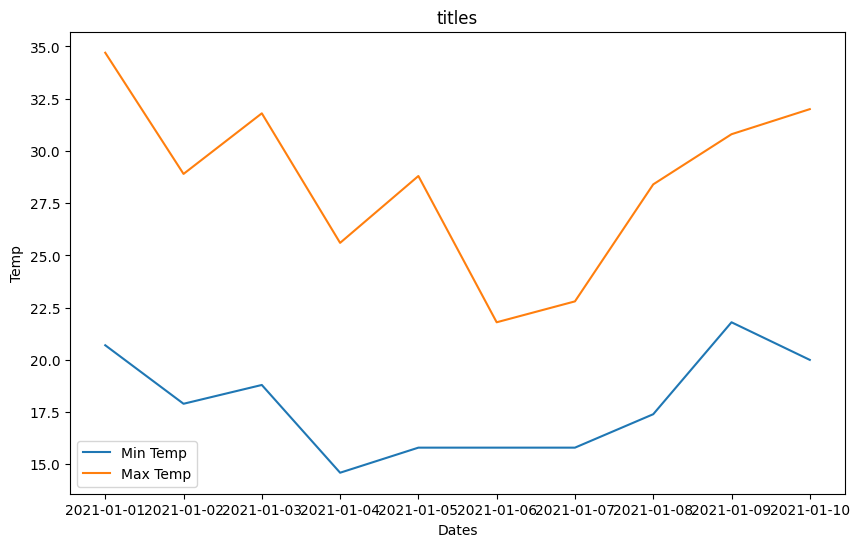

In [11]:
import matplotlib.pyplot as plt

dates = [
    '2021-01-01', '2021-01-02', '2021-01-03', '2021-01-04', '2021-01-05',
    '2021-01-06', '2021-01-07', '2021-01-08', '2021-01-09', '2021-01-10'
]
min_temperature = [20.7, 17.9, 18.8, 14.6, 15.8, 15.8, 15.8, 17.4, 21.8, 20.0]
max_temperature = [34.7, 28.9, 31.8, 25.6, 28.8, 21.8, 22.8, 28.4, 30.8, 32.0]

#항상 객체지향 형태로 문법 시작할 것에 주의!! 

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(dates, min_temperature, label = 'Min Temp')
ax.plot(dates, max_temperature, label = 'Max Temp')
ax.legend(loc=3)  # loc="lower left"로 할 수도 있음 # 문서 참고 https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.legend.html
ax.set_xlabel("Dates")
ax.set_ylabel("Temp")
ax.set_title("titles")
plt.show()

In [12]:
!pip install yfinance --upgrade --no-cache-dir

     ---------------------------------------- 0.0/3.0 MB ? eta -:--:--
     -------------------------- ------------- 2.0/3.0 MB 31.4 MB/s eta 0:00:01
     --------------------------------- ------ 2.5/3.0 MB 26.4 MB/s eta 0:00:01
     ---------------------------------------- 3.0/3.0 MB 23.5 MB/s eta 0:00:00
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
   ---------------------------------------- 0.0/73.5 kB ? eta -:--:--
   ---------------------------------------- 73.5/73.5 kB 4.0 MB/s eta 0:00:00
   ---------------------------------------- 0.0/112.2 kB ? eta -:--:--
   ---------------------------------------- 112.2/112.2 kB ? eta 0:00:00
   ---------------------------------------- 0.0/3.8 MB ? eta -:--:--
 


[notice] A new release of pip is available: 24.1 -> 24.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [15]:
import yfinance as yf
TSLA = yf.download("TSLA", start="2020-01-01", end="2024-07-02")
TSLA.head()

[*********************100%%**********************]  1 of 1 completed


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2020-01-02,28.299999,28.713333,28.114000,28.684000,28.684000,142981500
2020-01-03,29.366667,30.266666,29.128000,29.534000,29.534000,266677500
2020-01-06,29.364668,30.104000,29.333332,30.102667,30.102667,151995000
2020-01-07,30.760000,31.441999,30.224001,31.270666,31.270666,268231500
2020-01-08,31.580000,33.232666,31.215334,32.809334,32.809334,467164500


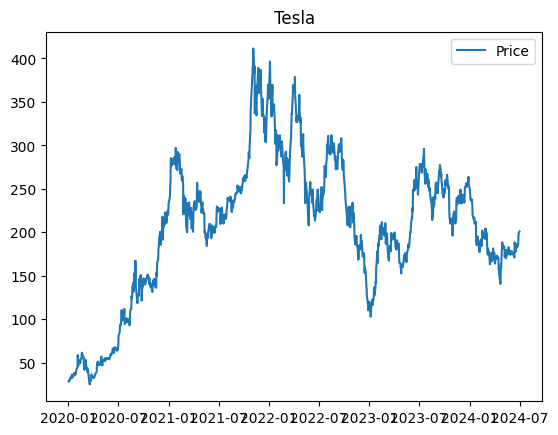

In [18]:
fig, ax = plt.subplots()
ax.plot(TSLA['Open'])
ax.set_title("Tesla")
ax.legend(labels = ['Price'], loc = 'best')
ax.set_xlabel('Date')
ax.set_xticklabels(TSLA['Open'].index, rotation=20) # 틱 레이블 인덱스를 20도 회전 
plt.show()

## seaborn 이용한 시각화

C:\Users\user\AppData\Local\Temp\ipykernel_12816\1430571292.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=['setosa', 'versicolor', 'virginica'])
C:\Users\user\AppData\Local\Temp\ipykernel_12816\1430571292.py:13: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


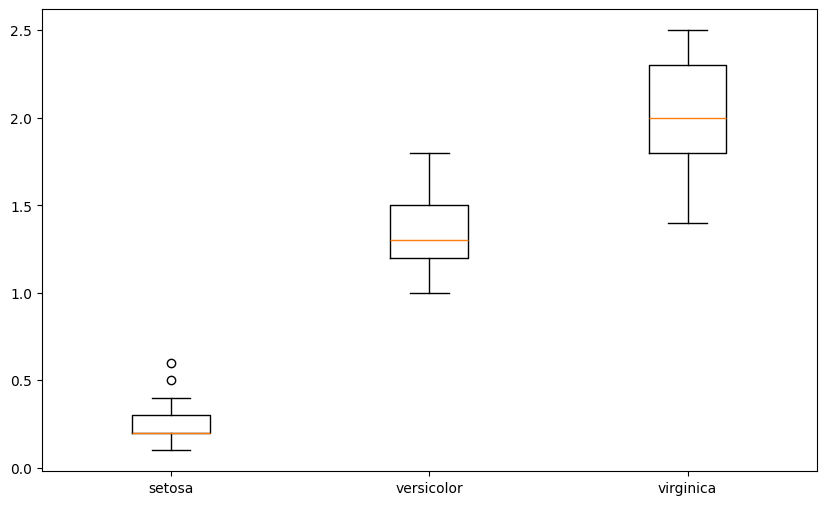

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

iris = sns.load_dataset('iris')

data = [iris[iris['species']=="setosa"]['petal_width'], 
        iris[iris['species']=="versicolor"]['petal_width'],
        iris[iris['species']=="virginica"]['petal_width']]

fig, ax = plt.subplots(figsize=(10, 6))
ax.boxplot(data, labels=['setosa', 'versicolor', 'virginica'])

fig.show()

<class 'matplotlib.axes._axes.Axes'>


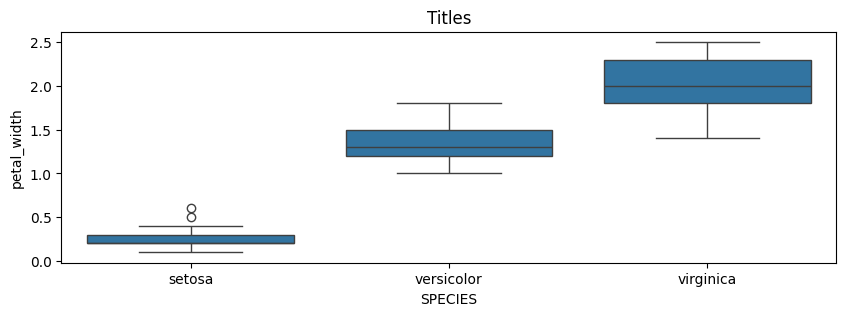

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

iris = sns.load_dataset('iris')

fix, ax = plt.subplots(figsize=(10,3))
sns.boxplot(data = iris, x = 'species', y = 'petal_width', ax = ax)
ax.set_title("Titles")
ax.set_xlabel("SPECIES")
print(type(ax))
plt.show()

## 막대 그래프 그려보기 

In [23]:
import matplotlib.pyplot as plt
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator, FuncFormatter)
import seaborn as sns
import numpy as np

## 데이터 불러오기 

In [25]:
tips = sns.load_dataset("tips")
tips.head(1)

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2


## 기초 데이터 

In [41]:
group_mean = tips.groupby(['day'],observed=False)['total_bill'].agg('mean')
h_day = group_mean.sort_values(ascending=False).index[0] # h_day = group_mean.idxmax()와 같음 
h_mean = float(np.round(group_mean.sort_values(ascending=False).values[0], 2))
h_day, h_mean

('Sun', 21.41)

# 축 옵션 UDF 함수 

In [58]:
def major_formatter(x, pos):
    return "%.2f$" % x
formatter = FuncFormatter(major_formatter)

## 시각화 객체 지향 선언 

17.68
17.15
20.44
21.41
Text(0, 0, 'Thur')
Text(1, 0, 'Fri')
Text(2, 0, 'Sat')
Text(3, 0, 'Sun')


C:\Users\user\AppData\Local\Temp\ipykernel_12816\3971356560.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax0.set_xticklabels(['Thursday', 'Friday', 'Saturday', 'Sunday'], size=12)


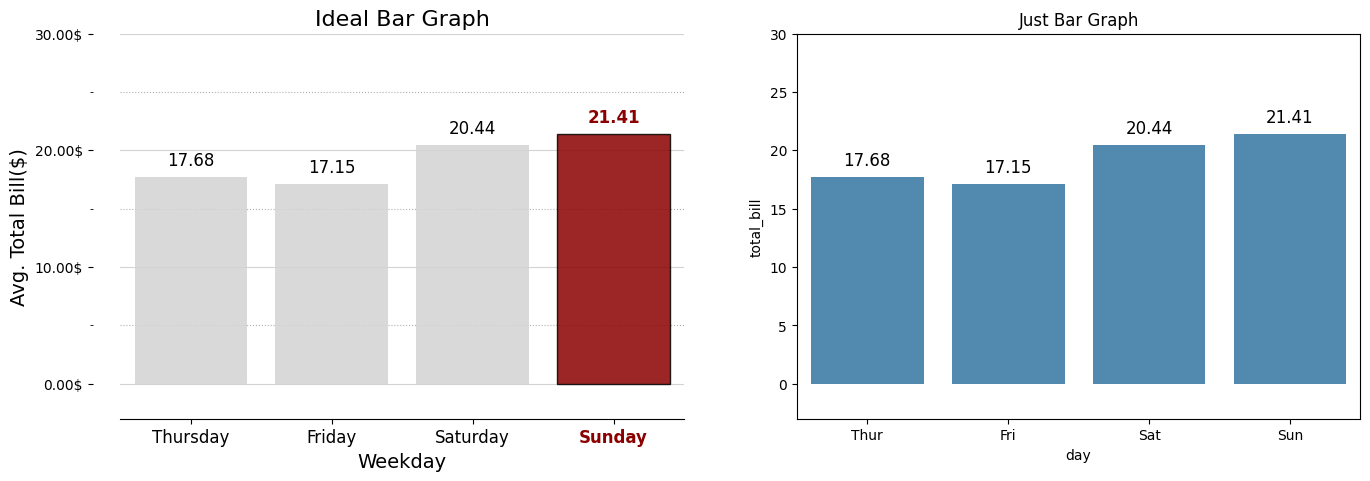

In [63]:
fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize=(16,5))
ax0 = sns.barplot(x = 'day', y = 'total_bill', data = tips,
                  errorbar=None, color = 'lightgray', alpha = 0.85, zorder = 2, 
                  ax = ax[0]) # 축이 오른쪽으로 표시 되기 떄문에 ax=ax[0]로 왼쪽에 옮김

for p in ax0.patches:
    #print(p, type(p))
    fontweight = 'normal'
    color = 'k'
    height = np.round(p.get_height(), 2)
    print(height)
    if h_mean == height:
        #height이 sunday면 색상 다르게 주겠다. 
        fontweight = 'bold'
        color = 'darkred'
        p.set_facecolor(color)
        p.set_edgecolor('black')
        
#    else: 
#    p.set_facecolor('lightgray')
#    p.set_edgecolor('black')
    
    # x축 위치 조정. width의 center에 오게끔 텍스트를 조정 
    ax0.text(p.get_x() + p.get_width()/2., height+1, 
             height, ha = 'center', size=12, fontweight=fontweight, color=color)

ax0.set_ylim(-3, 30)
ax0.set_title("Ideal Bar Graph", size = 16)

ax0.spines['top'].set_visible(False)
ax0.spines['left'].set_position(("outward", 20))
ax0.spines['left'].set_visible(False)
ax0.spines['right'].set_visible(False)

ax0.yaxis.set_major_locator(MultipleLocator(10))
ax0.yaxis.set_major_formatter(formatter)
ax0.yaxis.set_minor_locator(MultipleLocator(5))

ax0.set_ylabel("Avg. Total Bill($)", fontsize=14)

ax0.grid(axis="y", which="major", color="lightgray")
ax0.grid(axis="y", which="minor", ls=":")

#밑에 있는 thursday ~ sunday 등의 축 형태 변경 
ax0.set_xlabel("Weekday", fontsize=14)
for xtick in ax0.get_xticklabels():
  print(xtick)
  if xtick.get_text() == h_day:
    xtick.set_color("darkred")
    xtick.set_fontweight("demibold")
ax0.set_xticklabels(['Thursday', 'Friday', 'Saturday', 'Sunday'], size=12)


ax1 = sns.barplot(x = 'day', y = 'total_bill', data = tips, 
                  errorbar=None, alpha = 0.85, ax = ax[1])

for p in ax1.patches:
  height = np.round(p.get_height(), 2)
  ax1.text(p.get_x() + p.get_width()/2., height+1, height, ha = 'center', size=12)
ax1.set_ylim(-3, 30)
ax1.set_title("Just Bar Graph")

plt.show()